## (a) discover and visualise the data

### 1. Start Spark Session

In [ ]:
!pip install pyspark
!pip install findspark
import findspark
findspark.init()
import pyspark

# Import Spark library
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, mean, stddev, abs
from pyspark.sql import DataFrame
from pyspark.sql.functions import col, sum, log1p
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.tuning import ParamGridBuilder
from pyspark.ml.tuning import CrossValidator
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.classification import LinearSVC
from pyspark.ml.evaluation import MulticlassClassificationEvaluator,BinaryClassificationEvaluator
from pyspark.ml.feature import RFormula

import time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Build a SparkSession
spark = SparkSession.builder \
        .getOrCreate()

Explanation:  
The those libraries.  
== The code ==  
SparkSession: main entry point to use Spark. All Spark operation such as loading data, SQL queries and ML models start from SparkSession.  
.builder: used to configure how the SparkSession can be created.  
.getOrCreate: gets an existing SparkSession if already exists, else creates a new SparkSession.  

== The outcome ==   
No outcome is shown. However, this is a mandatory step for Spark building.

### 2. Load the Dataset (Spark DataFrame)

In [ ]:
# Read csv file with header
train_df = spark.read.csv(
    'UNSW_NB15_training-set.csv',
    header=True,
    inferSchema=True
)

# Read test dataset for testing purpose
test_df = spark.read.csv(
    'UNSW_NB15_testing-set.csv',
    header=True,
    inferSchema=True
)

# Show the content
train_df
train_df.show()

test_df
test_df.show()

+---+--------+-----+-------+-----+-----+-----+------+------+-----------+----+----+-----------+-----------+-----+-----+----------+----------+-----------+-----------+----+----------+----------+----+--------+--------+--------+-----+-----+-----------+-----------------+----------+------------+----------+----------------+----------------+--------------+------------+----------+----------------+----------+----------+---------------+----------+-----+
| id|     dur|proto|service|state|spkts|dpkts|sbytes|dbytes|       rate|sttl|dttl|      sload|      dload|sloss|dloss|    sinpkt|    dinpkt|       sjit|       djit|swin|     stcpb|     dtcpb|dwin|  tcprtt|  synack|  ackdat|smean|dmean|trans_depth|response_body_len|ct_srv_src|ct_state_ttl|ct_dst_ltm|ct_src_dport_ltm|ct_dst_sport_ltm|ct_dst_src_ltm|is_ftp_login|ct_ftp_cmd|ct_flw_http_mthd|ct_src_ltm|ct_srv_dst|is_sm_ips_ports|attack_cat|label|
+---+--------+-----+-------+-----+-----+-----+------+------+-----------+----+----+-----------+-----------+--

Explanation:  
== The code ==  
This algorithm reads the csv training data provided.  
.csv means to read the csv file.  
'header=true' instruct PySpark to read the first row  
inferSchema=true: Spark will automatically go through the csv file and infer the schema of each column.   

== The output ==  
The code is mandatory for Spark MLlib, .show() show the content for every attributes of the training and testing data.

### Check data imbalance

In [ ]:
train_df.groupBy("label").count().show()

+-----+------+
|label| count|
+-----+------+
|    1|119341|
|    0| 56000|
+-----+------+



In [ ]:
test_df.groupBy("label").count().show()

+-----+-----+
|label|count|
+-----+-----+
|    1|45332|
|    0|37000|
+-----+-----+



Explanation:  
We use groupBy to check how label is distributed.  
As the data is imbalance, we need to do stratification to prevent overfitting.  

### 3. Merge training and testing dataset

In [ ]:
# Merge train and test CSVs into one dataset
df_all = train_df.unionByName(test_df)

df_all.show()

+---+--------+-----+-------+-----+-----+-----+------+------+-----------+----+----+-----------+-----------+-----+-----+----------+----------+-----------+-----------+----+----------+----------+----+--------+--------+--------+-----+-----+-----------+-----------------+----------+------------+----------+----------------+----------------+--------------+------------+----------+----------------+----------+----------+---------------+----------+-----+
| id|     dur|proto|service|state|spkts|dpkts|sbytes|dbytes|       rate|sttl|dttl|      sload|      dload|sloss|dloss|    sinpkt|    dinpkt|       sjit|       djit|swin|     stcpb|     dtcpb|dwin|  tcprtt|  synack|  ackdat|smean|dmean|trans_depth|response_body_len|ct_srv_src|ct_state_ttl|ct_dst_ltm|ct_src_dport_ltm|ct_dst_sport_ltm|ct_dst_src_ltm|is_ftp_login|ct_ftp_cmd|ct_flw_http_mthd|ct_src_ltm|ct_srv_dst|is_sm_ips_ports|attack_cat|label|
+---+--------+-----+-------+-----+-----+-----+------+------+-----------+----+----+-----------+-----------+--

### 4. Outlier detection

In [ ]:
# Get all number columns
num_cols = [f.name for f in df_all.schema.fields
                if f.dataType.simpleString() in ["double", "float", "long", "integer"]]

total = df_all.count()

outlier_summary = {}

# Get the mean and standard deviation of all columns
for col_name in num_cols:
    stats = df_all.select(
        mean(col(col_name)).alias("mean"),
        stddev(col(col_name)).alias("stddev")
    ).collect()[0]

    mean_val = stats["mean"]
    std_val = stats["stddev"]

    count = df_all.filter(abs((col(col_name) - mean_val) / std_val) > 3).count()
    outlier_summary[col_name] = count

# Print out each outlier
print("Outlier counts per column:")
for k,v in outlier_summary.items():
    print(f"{k}: {v} ({v/total:.2%})")

Outlier counts per column:
dur: 4073 (1.58%)
rate: 4240 (1.65%)
sload: 4669 (1.81%)
dload: 8234 (3.20%)
sinpkt: 3568 (1.38%)
dinpkt: 1208 (0.47%)
sjit: 1673 (0.65%)
djit: 1743 (0.68%)
tcprtt: 1866 (0.72%)
synack: 1804 (0.70%)
ackdat: 2194 (0.85%)


Explanation:  
Outliers are detected because they can distort the learning process and make models overfit or misinterpret the data. We can learn outliers as the abnormal data that do not follow the usual pattern of our dataset. We can use this detection to understand whether they are noise or signal and decide whether remove or ignore them. As the outlier is too small (0-3%) and the dataset is extremely large, we will ignore them in this case.

### 5. Data Stratification

In [ ]:
def stratified_split(df: DataFrame, label_col: str, train_ratio: float, seed: int = 42):
    # Get distinct classes
    classes = [row[label_col] for row in df.select(label_col).distinct().collect()]

    train_parts = []
    test_parts = []

    for c in classes:
        # Filter rows of this class
        subset = df.filter(col(label_col) == c)
        # Split this subset randomly
        train_subset, test_subset = subset.randomSplit([train_ratio, 1-train_ratio], seed=seed)
        train_parts.append(train_subset)
        test_parts.append(test_subset)

    # Union all subsets back together
    train_df = train_parts[0]
    for part in train_parts[1:]:
        train_df = train_df.union(part)

    test_df = test_parts[0]
    for part in test_parts[1:]:
        test_df = test_df.union(part)

    return train_df, test_df

train_df, test_df = stratified_split(df_all, label_col="attack_cat", train_ratio=0.8, seed=42)

print("Train count:", train_df.count())
print("Test count:", test_df.count())
train_df.groupBy("label").count().show()
test_df.groupBy("label").count().show()

Train count: 206791
Test count: 50882
+-----+------+
|label| count|
+-----+------+
|    1|132404|
|    0| 74387|
+-----+------+

+-----+-----+
|label|count|
+-----+-----+
|    1|32269|
|    0|18613|
+-----+-----+



Explanation:  
As data is imbalance, we need to concat the training and testing dataset to do stratification.  
Firstky, the function collects all distinct class labels from our dataset, then looping through each class separately to split its rows into train and test subsets using the given ratio. By splitting each class independently, it guarantees that the same proportion of each class is preserved in both train and test sets. After splitting, it unions all the per‑class train subsets together into one training DataFrame, and does the same for the test subsets. The result is a stratified train/test split: both sets contain the same class distribution as the original dataset, which is especially important when dealing with imbalanced data.
It ensures train and test sets have the same class ratio (≈64% vs 36%). That is correct and consistent with the original dataset.


### 6. Preview the Data

In [ ]:
type(train_df)

pyspark.sql.classic.dataframe.DataFrame

In [ ]:
type(test_df)

pyspark.sql.classic.dataframe.DataFrame

Explanation:  
== The code ==  
type(train_df) and type(test_df) show the data type for this dataset.  
As they are read using Spark library, they are in sql format.


### 7. Simple Visualisation

In [ ]:
# Show the train_df detail
train_df.head()

Row(id=49960, dur=0.338518, proto='tcp', service='http', state='FIN', spkts=66, dpkts=14, sbytes=78481, dbytes=612, rate=233.370165, sttl=254, dttl=252, sload=1826597.125, dload=13446.84766, sloss=30, dloss=1, sinpkt=4.991231, dinpkt=25.489846, sjit=514.881352, djit=38.656297, swin=255, stcpb=2381717425, dtcpb=307268346, dwin=255, tcprtt=0.05277, synack=0.007146, ackdat=0.045624, smean=1189, dmean=44, trans_depth=1, response_body_len=0, ct_srv_src=1, ct_state_ttl=1, ct_dst_ltm=1, ct_src_dport_ltm=1, ct_dst_sport_ltm=1, ct_dst_src_ltm=1, is_ftp_login=0, ct_ftp_cmd=0, ct_flw_http_mthd=1, ct_src_ltm=1, ct_srv_dst=1, is_sm_ips_ports=0, attack_cat='Worms', label=1)

In [ ]:
# Show the test_df detail
test_df.head()

Row(id=51267, dur=5e-06, proto='udp', service='-', state='INT', spkts=2, dpkts=0, sbytes=2050, dbytes=0, rate=200000.0051, sttl=254, dttl=0, sload=1640000000.0, dload=0.0, sloss=0, dloss=0, sinpkt=0.005, dinpkt=0.0, sjit=0.0, djit=0.0, swin=0, stcpb=0, dtcpb=0, dwin=0, tcprtt=0.0, synack=0.0, ackdat=0.0, smean=1025, dmean=0, trans_depth=0, response_body_len=0, ct_srv_src=1, ct_state_ttl=2, ct_dst_ltm=1, ct_src_dport_ltm=1, ct_dst_sport_ltm=1, ct_dst_src_ltm=1, is_ftp_login=0, ct_ftp_cmd=0, ct_flw_http_mthd=0, ct_src_ltm=1, ct_srv_dst=2, is_sm_ips_ports=0, attack_cat='Worms', label=1)

Explain:  
== The code ==  
.head() in Spark will show a single row of object, that is the first line of the data. The first row of data will come with attribute name, and the corresponding data.

### 8. View Dataset Structure

In [ ]:
train_df.printSchema()

root
 |-- id: integer (nullable = true)
 |-- dur: double (nullable = true)
 |-- proto: string (nullable = true)
 |-- service: string (nullable = true)
 |-- state: string (nullable = true)
 |-- spkts: integer (nullable = true)
 |-- dpkts: integer (nullable = true)
 |-- sbytes: integer (nullable = true)
 |-- dbytes: integer (nullable = true)
 |-- rate: double (nullable = true)
 |-- sttl: integer (nullable = true)
 |-- dttl: integer (nullable = true)
 |-- sload: double (nullable = true)
 |-- dload: double (nullable = true)
 |-- sloss: integer (nullable = true)
 |-- dloss: integer (nullable = true)
 |-- sinpkt: double (nullable = true)
 |-- dinpkt: double (nullable = true)
 |-- sjit: double (nullable = true)
 |-- djit: double (nullable = true)
 |-- swin: integer (nullable = true)
 |-- stcpb: long (nullable = true)
 |-- dtcpb: long (nullable = true)
 |-- dwin: integer (nullable = true)
 |-- tcprtt: double (nullable = true)
 |-- synack: double (nullable = true)
 |-- ackdat: double (nullable 

In [ ]:
test_df.printSchema()

root
 |-- id: integer (nullable = true)
 |-- dur: double (nullable = true)
 |-- proto: string (nullable = true)
 |-- service: string (nullable = true)
 |-- state: string (nullable = true)
 |-- spkts: integer (nullable = true)
 |-- dpkts: integer (nullable = true)
 |-- sbytes: integer (nullable = true)
 |-- dbytes: integer (nullable = true)
 |-- rate: double (nullable = true)
 |-- sttl: integer (nullable = true)
 |-- dttl: integer (nullable = true)
 |-- sload: double (nullable = true)
 |-- dload: double (nullable = true)
 |-- sloss: integer (nullable = true)
 |-- dloss: integer (nullable = true)
 |-- sinpkt: double (nullable = true)
 |-- dinpkt: double (nullable = true)
 |-- sjit: double (nullable = true)
 |-- djit: double (nullable = true)
 |-- swin: integer (nullable = true)
 |-- stcpb: long (nullable = true)
 |-- dtcpb: long (nullable = true)
 |-- dwin: integer (nullable = true)
 |-- tcprtt: double (nullable = true)
 |-- synack: double (nullable = true)
 |-- ackdat: double (nullable 

Explanation:  
== The code ==  
This steps shows columns name and data types (int, double, string). It helps identify numerical and categorical attributes, to let us more understand about the dataset.  

== The outcome ==  
This steps shows columns name and data types (int, double, string).

### 9. Basic Statistics (Numerical Overview)

In [ ]:
train_df.describe().show()

+-------+------------------+------------------+------+-------+------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+-------------------+------------------+-----------------+-----------------+-----------------+------------------+-----------------+------------------+------------------+--------------------+--------------------+------------------+-------------------+-------------------+--------------------+------------------+------------------+-------------------+-----------------+------------------+------------------+------------------+-----------------+-----------------+------------------+--------------------+--------------------+-------------------+-----------------+------------------+--------------------+----------+------------------+
|summary|                id|               dur| proto|service| state|             spkts|             dpkts|            sbytes|            dbytes|             rate|       

In [ ]:
test_df.describe().show()

+-------+-----------------+------------------+-----+-------+-----+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+--------------------+------------------+-----------------+-----------------+-----------------+------------------+------------------+------------------+------------------+--------------------+--------------------+------------------+-------------------+--------------------+-------------------+------------------+------------------+-------------------+-----------------+------------------+------------------+-----------------+-----------------+-----------------+------------------+-------------------+--------------------+-------------------+-----------------+------------------+--------------------+----------+------------------+
|summary|               id|               dur|proto|service|state|             spkts|             dpkts|           sbytes|            dbytes|              rate|             

Explanation:  
== The code ==  
train_df and test_df are the dataset, describe() shows the numerical features, show() gives us visualisation.  

== The outcome ==  
This provides an overview of numerical features distributions, including count, mean, std, min and max of datasets to help detect outliers or abnormal values.  


#### 10. Visualise distribution

<Axes: title={'center': 'Distribution of Label (Normal vs Attack)'}, xlabel='label'>

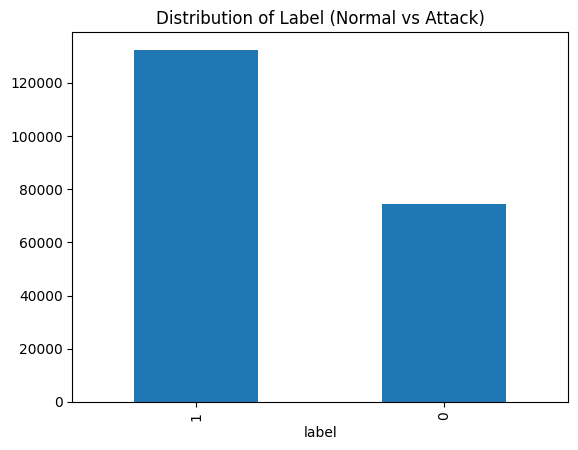

In [ ]:
# Count the number of data group by the attribute "label"
# Convert it into Pandas
label_pd = train_df.groupBy("label").count().toPandas()

label_pd.plot(
    x="label",
    y="count",
    kind="bar",
    title="Distribution of Label (Normal vs Attack)",
    legend=False
)


<Axes: title={'center': 'Distribution of Test Label (Normal vs Attack)'}, xlabel='label'>

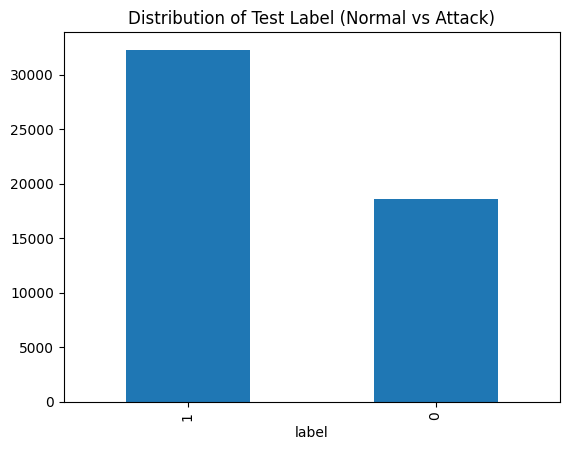

In [ ]:
# Count the number of data group by the attribute "label"
# Convert it into Pandas
test_label_pd = test_df.groupBy("label").count().toPandas()

test_label_pd.plot(
    x="label",
    y="count",
    kind="bar",
    title="Distribution of Test Label (Normal vs Attack)",
    legend=False
)


Explanation:  
== The code ==  
As Spark cannot support plotting, we will convert it to Pandas for visualisation. We get the label_pd by counting the number of data group by ("label"). For example we have two categories: label 1 and 0. The function count the number of categories respectively, then use toPandas() to convert it to Pandas. After that, we can use Pandas plotting to show the histogram. We set x as label attribute, so differentiate to 0 (normal) and 1 (attack) according to the dataset. Y shows the value, kind = "bar" so the data will show in histogram, title will be put above the graph.  

== The outcome ==  
It will clearly show the data same as the cell above but in plotting instead of giving a simple table.

### 11. Check Missing Values

In [ ]:
# Show in one row
train_df.select([
    # Calculate the missing values
    sum(col(c).isNull().cast("int")).alias(c)
    # For each attribute
    for c in train_df.columns
   # Show the result
]).show()

# Show in one row
test_df.select([
    # Calculate the missing values
    sum(col(c).isNull().cast("int")).alias(c)
    # For each attribute
    for c in test_df.columns
   # Show the result
]).show()


+---+---+-----+-------+-----+-----+-----+------+------+----+----+----+-----+-----+-----+-----+------+------+----+----+----+-----+-----+----+------+------+------+-----+-----+-----------+-----------------+----------+------------+----------+----------------+----------------+--------------+------------+----------+----------------+----------+----------+---------------+----------+-----+
| id|dur|proto|service|state|spkts|dpkts|sbytes|dbytes|rate|sttl|dttl|sload|dload|sloss|dloss|sinpkt|dinpkt|sjit|djit|swin|stcpb|dtcpb|dwin|tcprtt|synack|ackdat|smean|dmean|trans_depth|response_body_len|ct_srv_src|ct_state_ttl|ct_dst_ltm|ct_src_dport_ltm|ct_dst_sport_ltm|ct_dst_src_ltm|is_ftp_login|ct_ftp_cmd|ct_flw_http_mthd|ct_src_ltm|ct_srv_dst|is_sm_ips_ports|attack_cat|label|
+---+---+-----+-------+-----+-----+-----+------+------+----+----+----+-----+-----+-----+-----+------+------+----+----+----+-----+-----+----+------+------+------+-----+-----+-----------+-----------------+----------+------------+-----

Explanation:  
== The code ==   
Import col and sum function from pyspark.sql.functions.  
df.select([]) selects one aggregation per column, so the output DataFrame has one row, one column per original column. In this case, after sum(col(c).isNull().cast("int")).alias(c) for c in df.columns is added inside, each value shows the number of missing values.  
for c in df.columns, means that a list comprehension that loop through every column in df. We use for loop to take each column one by one.   
col(c) is to convert the column name from String to Spark Column object so Spark can operate on it. col(c).isNull() checks row by row whether the value in col(c) is NULL, the outcome will come with boolean. However, with cast("int"), the outcome will from "Yes" or "No" changed to 1 or 0 respectively. Therefore, 1 for missing and 0 for not missing. Then, the sum(col(c).isNull().cast("int")) adds up all the 1 in that column, so we can get the total number of NULL values in column c.alias(c) names the output column using the original column name, so the result remains easy to read.   
Lastly, show() display the result.  
Missing value analysis helps determine the need for data cleaning and imputation during preprocessing.  

== The outcome ==  
A row of attributes with attribute name at first line and number of missing values at the second line, as we can clearly visualise which columns have missing values. There is no missing value in this dataset.

### 12. Handle missing values for safe

In [ ]:
# Note: how = any means rows where any of the attributes value is null will be removed
train_df = train_df.na.drop(how = 'any')
test_df = test_df.na.drop(how = 'any')

# Check again the missing value to ensure that no missing value.
# Show in one row
train_df.select([
    # Calculate the missing values
    sum(col(c).isNull().cast("int")).alias(c)
    # For each attribute
    for c in train_df.columns
   # Show the result
]).show()

# Show in one row
test_df.select([
    # Calculate the missing values
    sum(col(c).isNull().cast("int")).alias(c)
    # For each attribute
    for c in test_df.columns
   # Show the result
]).show()


+---+---+-----+-------+-----+-----+-----+------+------+----+----+----+-----+-----+-----+-----+------+------+----+----+----+-----+-----+----+------+------+------+-----+-----+-----------+-----------------+----------+------------+----------+----------------+----------------+--------------+------------+----------+----------------+----------+----------+---------------+----------+-----+
| id|dur|proto|service|state|spkts|dpkts|sbytes|dbytes|rate|sttl|dttl|sload|dload|sloss|dloss|sinpkt|dinpkt|sjit|djit|swin|stcpb|dtcpb|dwin|tcprtt|synack|ackdat|smean|dmean|trans_depth|response_body_len|ct_srv_src|ct_state_ttl|ct_dst_ltm|ct_src_dport_ltm|ct_dst_sport_ltm|ct_dst_src_ltm|is_ftp_login|ct_ftp_cmd|ct_flw_http_mthd|ct_src_ltm|ct_srv_dst|is_sm_ips_ports|attack_cat|label|
+---+---+-----+-------+-----+-----+-----+------+------+----+----+----+-----+-----+-----+-----+------+------+----+----+----+-----+-----+----+------+------+------+-----+-----+-----------+-----------------+----------+------------+-----

Explanation:  
== The code ==  
na.drop(how = 'any') means that it will drop any null values that appear in the dataset.  
As Spark cannot change the original version, we just can overlap it with a new variable.  

== The outcome ==  
Visualise again by finding the missing value again to ensure that no missing value.  

## (b) prepare the data for machine learning algorithms

#### 1. Select target and remove invalid rows

In [ ]:
# Select target
target_column = "label"

# Drop another target to avoid effect another target
df_clean = train_df.drop("attack_cat")

# Print out the target
print("Training model for target:", target_column)

# Ensure no null labels exist
df_target = train_df.filter(train_df[target_column].isNotNull())

Training model for target: label


Explanation:  
== The code ==  
Firstly, we define our target as "label".   
"attack_cat" as another target column also been dropped to avoid data leakage.   
Then, we print out our target.   
The df.filter line removes rows where the target variable is missing. It means that if the row shows "NULL" in "label" attribute, it will be removed. It is necessary because machine learning models cannot learn without labels, it cannot be trained or evaluated. It is a mandatory cleaning step to prevent runtime errors during training.  

== The outcome ==  
As we just print the targets. Those invalid rows (with null) will be removed.


#### 2. Drop non-predictive columns

In [ ]:
# Define the need to be dropped columns
drop_cols = ["id"]

# Use drop() to drop it
df_clean = df_clean.drop(*drop_cols)

Explanation:  
== The code ==  
We use this cell to write algorithm to delete those unpredictive columns, as example the "id" is not useful is creating a model but effect the efficiency. Thus we use this cell to drop those columns to increase modelling effectiveness. As we might drop more than one column, we will set drop_cols as a list for scalability. Therefore, we can easily add or remove columns and manage them in one place. df_clean = df_clean.drop(*drop_cols) we use * to represents we delete all together instead of typing them one by one manually.   

== The outcome ==  
No outcome is shown, but those attributes specified in the list will be deleted.

#### 3. Identify categorical and numerical columns

In [ ]:
# Differentiate which columns have categorical data
categorical_cols = [f.name for f in df_clean.schema.fields
                    if f.dataType.simpleString() == "string"]

# Differentiate which columns have numerical data
numerical_cols = [f.name for f in df_clean.schema.fields
                  if f.name not in categorical_cols + [target_column]]
# We did not delete the target column in train_df for further comparison, but we
# exclude the target column here to avoid it used as training feature.
# Use this cell for RFormula base logic explanation

Explanation:  
== The code ==  
We need to differentiate the data types of each attributes as different data types need different preprocessing. In Spark, a DataFrame has a schema showing (column names + data types. We are running for loop for each column, it will identify which attribute is integer or string using f.dataType.simpleString() == "string". f.name in front represents the column names. Therefore, it will create a list that fill in with column names.  
For the next line, we need to identify which columns are numrical. By getting the numerical columns, we must exclude the categorical columns and target column by using not in categorical_cols + [target_column]("label").

The dataset was cleaned by removing null labels and non-predictive attributes.  
We identify numerical and categorical features for RFormula base logic explanation.  

#### 4. R-Formula

In [ ]:
'''
This cell is used to explain the base logic that we cannot see when using RFormula

# Stage 1: String Indexing for categorical features
# Use 'handleInvalid="keep"' to assign a new index for unseen labels
indexers = [ StringIndexer(inputCol=column, outputCol=column + "_indexed", handleInvalid="keep")
             for column in categorical_cols ]

# Stage 2: One-Hot Encoding for indexed categorical features
encoders = [
    #Convert each numerical columns with "_indexed" into one-hot vector
    OneHotEncoder(inputCol=column + "_indexed", outputCol=column + "_encoded")
    for column in categorical_cols
]

# Stage 3: Assemble all features into a single vector
#Collect all feature columns: encoded categorical + numerical
feature_cols = [column + "_encoded" for column in categorical_cols] + numerical_cols
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Create a Pipeline with all stages
pipeline_stages = indexers + encoders + [assembler]
feature_pipeline = Pipeline(stages=pipeline_stages)

# Fit the pipeline to the training data
pipeline_model = feature_pipeline.fit(df_clean)

# Transform the training data using the fitted pipeline model
df_transformed = pipeline_model.transform(df_clean)
'''

In [ ]:
# Define RFormula with a new feature
formula = RFormula(
    formula="label ~ . + (dur * rate)", # use all columns except the label column as features
    featuresCol="features",
    labelCol="label",
    handleInvalid="keep"
)

# Fit the formula on the training data and transform it
formula_model = formula.fit(df_clean)
df_prepared = formula_model.transform(df_clean)

# Select the final columns for modeling
df_prepared = df_prepared.select("features", "label")

# Show first 5 rows
df_prepared.show(5)

+--------------------+-----+
|            features|label|
+--------------------+-----+
|(196,[0,1,136,147...|    1|
|(196,[0,1,136,147...|    1|
|(196,[0,1,136,147...|    1|
|(196,[0,1,136,147...|    1|
|(196,[0,1,136,147...|    1|
+--------------------+-----+
only showing top 5 rows


Explanation:  
== The code ==  
The RFormula transformer was used to convert categorical string features (show one-hot encoded features) into numeric features, and combines everything into one new feature vector required by Spark MLlib models.  

Spark automatically performs three things:  
StringIndexer: convert categories into numeric indexes  
OneHotEncoder: convert categorical index into one-hot vector  
VectorAssembler: combine encoded categorical vector and numerical columns into a single vector  

We use RFormula to define new feature.
formula="label ~ . + (dur * rate): label ~ . means "predict label using all existing columns  + (dur * rate) adds the new interaction feature.  
featuresCol="features" use the existing features.  
labelCol="label": our target column  

We apply .fit() on the training data to learn categories, and .transform() to generate the final prepared dataset.   
Then we use .select() to get the final format ready for modeling.  

RFormula is used for:  
Simplifies pipelines:   
Instead of manually indexing, encoding, and assembling, RFormula does it in one step.  
Consistency:   
Ensures preprocessing is standardised across training and test datasets.


#### 5. Do preprocessing on test data

In [ ]:
# Clean the test_df similar to how train_df was cleaned
test_df_clean = test_df.drop("attack_cat")
test_df_clean = test_df_clean.drop(*drop_cols)

# Use RFormula to transform test_df
test_df_prepared = formula_model.transform(test_df_clean)

# Select only the features and label columns
test_df_prepared = test_df_prepared.select("features", "label")

# Visualise the outcome
test_df_prepared.show(5)

+--------------------+-----+
|            features|label|
+--------------------+-----+
|(196,[0,2,134,148...|    1|
|(196,[0,1,136,147...|    1|
|(196,[0,1,136,147...|    1|
|(196,[0,1,136,147...|    1|
|(196,[0,1,136,147...|    1|
+--------------------+-----+
only showing top 5 rows


Explanation:  
== The code ==  
Do the same pre-processing steps to the test_data to start prediction.    
Use the RFormula to transform test_df data, same as what we did with train_df.  

### (c) select and train models

### First model: Decision Tree

#### 1.1 Create Decision Tree model

In [ ]:
from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    labelCol="label",
    featuresCol="features",    # New features we created above
    impurity="entropy",
    maxDepth=20,               # pre-pruning step, captures more complex patterns
    minInstancesPerNode=50     # pre-pruning step, reduces overfitting
)

Explanation:  
== The code ==  
We define the Decision Tree in this cell.   
labelCol="label" is the target column.  
featuresCol="features" specifies the input features vector used for training. The "features" was created before using RFormula. We create this as Spark ML models do not read raw models, they only read the feature vector, where we already convert it into numerical values.   
impurity="entropy" is used to choose whether we use "entropy" or "gini".  
maxDepth=20 limits the maximum depth of the decision tree. If we have larger depth, the decision tree will be more complex. If the depth is smaller, the model will be simpler. This is a pre-pruning technique to control model complexity and avoid overfitting.   
minInstancesPerNode=50 fixes the minimum number of training instances required in each leaf node. If a node has fewer than 50 samples, it will not be split further. This helps reduce overfitting and improves generalisation.  

== The outcome ==  
No outcome is shown. However, a decision tree with variables we define will be created.  


### (d) fine-tune the model
In the fine-tuning step, we adjusted key hyperparameters of the Decision Tree and Logistic Regression models, such as tree depth and regularization strength. The tuned models were evaluated and compared with the baseline versions. The results show that appropriate parameter selection can improve predictive performance and reduce overfitting.

In [ ]:
# Creates a grid of hyperparameters to test.
paramGrid = ParamGridBuilder() \
    .addGrid(dt.impurity, ["gini", "entropy"]) \
    .addGrid(dt.maxDepth, [10, 15, 20]) \
    .addGrid(dt.minInstancesPerNode, [10, 50, 100]) \
    .build()

Explanation:  
With this step, I no need to change the variable above manually but it will help me to find-tune and find the best pair.  
Spark will try:   
(10, 10), (10, 50), (10, 100), (15, 10), (15, 50), (15, 100),   
(20, 10), (20, 50), (20, 100) in maxDepth and minInstancesPerNode with Gini index and Entropy respectively.  
maxDepth is the depth of decision tree, as decision tree can be very depth, we can set the maxDepth to avoid overfitting. As without a depth limit, the tree will grow until it perfectly classifies all the data points in the training set. This may results an extremely complex model.  
minInstancesPerNode try the minimum samples per node before the tree is allowed to split that node further. If a node has fewer samples than this threshold, the algorithm stops splitting and makes that node a leaf (final prediction).   
build() produces all combinations.  

#### 1.2 Train the model

In [ ]:
# Record the start time
start_time = time.time()

# Define an evaluator
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

# Set up CrossValidator
cv = CrossValidator(
    estimator=dt,                # the DecisionTree model
    estimatorParamMaps=paramGrid, # the grid we defined
    evaluator=evaluator,
    numFolds=5                   # k-fold cross validation
)

# Fit the model
dt_model = cv.fit(df_prepared)

# Record the end time
end_time = time.time()

# Calculate the execution time
dt_execution_time = end_time - start_time

# Extract the best model
dt_bestModel = dt_model.bestModel

#Print best hyperparameters
print("Best Impurity Method:", dt_bestModel.getImpurity())
print("Best maxDepth:", dt_bestModel._java_obj.getMaxDepth())
print("Best minInstancesPerNode:", dt_bestModel._java_obj.getMinInstancesPerNode())
print(f"Model Training completed in: {dt_execution_time:.2f} seconds")


Best Impurity Method: gini
Best maxDepth: 20
Best minInstancesPerNode: 10
Model Training completed in: 4587.98 seconds


Explanation:  
== The code ==  
MulticlassClassificationEvaluator: Used for multi class classification tasks.  
metricName="f1": evaluates models based on the f1-score. As the data is imbalance, we need to use F1-Score to have a more accurate result. As it has a more balanced precision and recall rate.  

CrossValidator: automates hyperparameter tuning with cross-validation.  
estimator=dt: use the defined decision tree model
estimatorParamMaps=paramGrid: the hyperparameters to test  
evaluator=evaluator: how to measure performance (F1-Score)  
numFolds=5: splits training data into 5 folds for cross-validation, and the best one is chosen. Spark does not provide a built‑in StratifiedKFold like scikit‑learn. For most datasets, especially when they are large or reasonably balanced, random k‑fold splits are sufficient and give stable performance estimates in Cross Validator. It is suitable when our dataset is stratified before and almost balanced.    

dt_model = cv.fit(df_prepared): fits the cross-validation process on the prepared training data. It will start to train multiple decision trees with different hyperparameters so use longer runtime. At the end, it will select the best-performing model based on F1-Score (we set before).  

dt_bestModel = dt_model.bestModel:  The single DecisionTreeClassifier trained with the best hyperparameters. We will use this for predictions.  

We use execution time = end time - start time to calculate the execution time.  

== The outcome ==   
Print out the tested best hyperparameter that will give the best outcome.


#### 1.3 Make predictions on test data

In [ ]:
# Record the start time
start_time = time.time()

# Make predictions on the prepared test data
dt_predictions = dt_bestModel.transform(test_df_prepared)

# Record the end time
end_time = time.time()

# Calculate the execution time
dt_inference_time = end_time - start_time

print(f"Decision Tree inference time: {dt_inference_time:.2f} seconds")

Decision Tree inference time: 0.07 seconds


Explanation:  
== The code ==   
Use the best model with best hyperparameter we found before to start prediction by using the test dataset.   

### (e) evaluate the outcomes

#### 1.4 View sample predictions

In [ ]:
# Display the actual label, the predicted label and the probability.
dt_predictions.select(
    "label", "prediction", "probability"
).show(15)


+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|    1|       1.0|[0.01639344262295...|
|    1|       1.0|[0.00420462508759...|
|    1|       1.0|[0.00737028301886...|
|    1|       1.0|[0.00531914893617...|
|    1|       1.0|[0.00420462508759...|
|    1|       1.0|[0.00737028301886...|
|    1|       1.0|[0.00506585612968...|
|    1|       1.0|[0.05399568034557...|
|    1|       1.0|[0.00420462508759...|
|    1|       1.0|[0.00737028301886...|
|    1|       1.0|[0.00420462508759...|
|    1|       1.0|[0.00506585612968...|
|    1|       1.0|[0.00737028301886...|
|    1|       1.0|           [0.0,1.0]|
|    1|       1.0|[0.05399568034557...|
+-----+----------+--------------------+
only showing top 15 rows


Explanation:  
== The code ==  
Whis shows actual label, predicted label, and confidence of prediction.  

#### 1.5 AUC Calculation

In [ ]:
dt_auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC" )
dt_auc = dt_auc_evaluator.evaluate(dt_predictions)

# Print the AUC result
print(f"Decision Tree AUC:={dt_auc} ({dt_auc * 100:.2f} %)")

Decision Tree AUC:=0.973783805814516 (97.38 %)


Explanation:  
== The code ==  
AUC stands for Area Under the ROC Curve. It measures how well a model can distinguish between classes (e.g. attack or normal).  
We use AUC as it robust to class imbalance and preferred for intrusion detection. It is better than accuracy alone.  
If the AUC value is 1, it is a perfect classifier. If the value is 0.9 +, it is excellent. While 0.8-0.9 is good, 0.7-0.8 is fair, but 0.5 is random guessing.  

#### 1.6 Accuracy calculation

In [ ]:
#1. Initialize the evaluator
dt_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction"
)

#2. Calculate each metric by changing the metricName
dt_accuracy = dt_evaluator.evaluate(dt_predictions, {dt_evaluator.metricName: "accuracy"})
dt_precision = dt_evaluator.evaluate(dt_predictions, {dt_evaluator.metricName: "weightedPrecision"})
dt_recall = dt_evaluator.evaluate(dt_predictions, {dt_evaluator.metricName: "weightedRecall"})
dt_f1_score = dt_evaluator.evaluate(dt_predictions, {dt_evaluator.metricName: "f1"})

#3. Print the results clearly
print("-" * 30)
print(f"Decision Tree Metrics:")
print("-" * 30)
print(f"Accuracy:  {dt_accuracy * 100:.2f}%")
print(f"Precision: {dt_precision * 100:.2f}%")
print(f"Recall:    {dt_recall * 100:.2f}%")
print(f"F1-Score:  {dt_f1_score * 100:.2f}%")

print("-" * 30)

------------------------------
Decision Tree Metrics:
------------------------------
Accuracy:  93.97%
Precision: 93.99%
Recall:    93.97%
F1-Score:  93.98%
------------------------------


Explanation:  
== The code ==  
We use MulticlassClassificationEvaluator to calculate accuracy, precision, recall and f1-Score, this function works like classification report in Scikit-Learn.  

== The outcome ==  
We can observe the performance metrics for comparison afterwards.  

#### 1.7 Tree structure visualisation

In [ ]:
print(dt_bestModel.toDebugString)

DecisionTreeClassificationModel: uid=DecisionTreeClassifier_7a89563a79da, depth=20, numNodes=2021, numClasses=2, numFeatures=195
  If (feature 162 <= 61.0)
   If (feature 168 <= 0.0015)
    If (feature 184 <= 0.5)
     Predict: 0.0
    Else (feature 184 > 0.5)
     If (feature 3 in {1.0})
      Predict: 0.0
     Else (feature 3 not in {1.0})
      Predict: 1.0
   Else (feature 168 > 0.0015)
    Predict: 0.0
  Else (feature 162 > 61.0)
   If (feature 187 <= 2.5)
    If (feature 193 <= 1.5)
     If (feature 176 <= 0.118807)
      If (feature 159 <= 109.0)
       If (feature 1 in {1.0})
        If (feature 179 <= 49.5)
         If (feature 183 <= 2.5)
          Predict: 1.0
         Else (feature 183 > 2.5)
          If (feature 156 <= 8.5E-6)
           Predict: 0.0
          Else (feature 156 > 8.5E-6)
           Predict: 1.0
        Else (feature 179 > 49.5)
         If (feature 185 <= 1.5)
          If (feature 161 <= 750000.0021500001)
           If (feature 156 <= 1.0500000000000001

Explanation:  
== The code ==  
Spark MLlib does not provide a built-in graphical visualisation for decision trees. Therefore, the tree structure is examined using the toDebugString method, which outputs the splitting rules and predictions in a textual format.  

== The outcome ==  
Describe root feature, depth and splitting logic

#### 1.8 Show confusion matrix

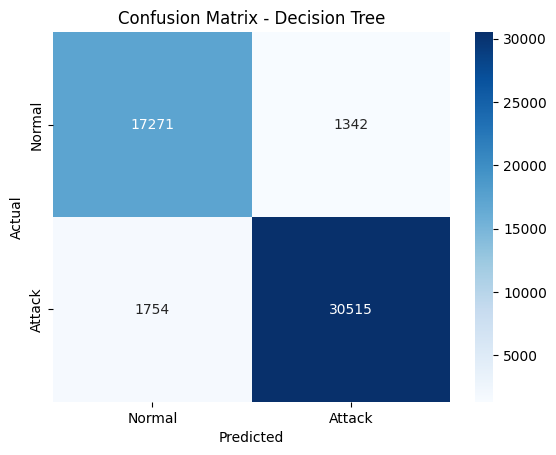

In [ ]:
#Calculate counts for the confusion matrix
#True Negative (label=0, prediction=0)
tn = dt_predictions.filter((dt_predictions.label == 0) & (dt_predictions.prediction == 0)).count()
#False Positive (label=0, prediction=1)
fp = dt_predictions.filter((dt_predictions.label == 0) & (dt_predictions.prediction == 1)).count()
#False Negative (label=1, prediction=0)
fn = dt_predictions.filter((dt_predictions.label == 1) & (dt_predictions.prediction == 0)).count()
#True Positive (label=1, prediction=1)
tp = dt_predictions.filter((dt_predictions.label == 1) & (dt_predictions.prediction == 1)).count()

#Create the confusion matrix (Actual vs. Predicted)
conf_matrix = np.array([
    [tn, fp],
    [fn, tp]
])

cm = conf_matrix

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Attack"],
            yticklabels=["Normal", "Attack"])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
dt_predictions.groupBy("label", "prediction").count().show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       1.0|30515|
|    1|       0.0| 1754|
|    0|       0.0|17271|
|    0|       1.0| 1342|
+-----+----------+-----+



A Decision Tree classifier was trained using Spark MLlib to predict whether a network record represents an attack or normal activity.  
Pre-pruning was applied by limiting the tree depth to reduce overfitting.

### 2. Second model: Logistic Regression

Logistic Regression is a widely used linear classification algorithm for binary outcomes. It models the probability that a record belongs to the positive class using a logistic (sigmoid) function. It is efficient, interpretable, and suitable as a strong baseline model for intrusion detection tasks.

#### 2.1 Define the Logistic Regression model

In [ ]:
#Define the Logistic Regression model
lr = LogisticRegression(
    featuresCol="features",   # Input feature vector
    labelCol="label",         # Target column
    maxIter=80,               # Training iterations
    regParam=0.01,            # Regularization strength (prevents overfitting)
    elasticNetParam=0.4       # L2 regularization
)


Explanation:  
== The code ==  
featuresCol="features" specifies the input feature vector column.  
In Spark, all features must be combined into one vector column, we will use the feature we created in RFormula.  
labelCol="label" is the target column.  
maxIter=80 controls the maximum number of training iterations. We need to set this because we need more iterations for better convergence, but too many will cause slow training. Therefore we need to find tune to find the best maxIter.  
regParam=0.01 is the regularization strength, used to prevent overfitting. 0.0 means no regularization, larger value represents stronger penalty, so 0.01 is a reasonable default.  
elasticNetParam=0.4 controls the type of regularization, 0.0 is L2, 1.0 is L1. Currect value 0.4 means mostly L2, with some L1.  

### (d) fine-tune the model


In [ ]:
#Creates a grid of hyperparameters to test.
paramGrid = (
    ParamGridBuilder()
    .addGrid(lr.regParam, [0.001, 0.01, 0.1])
    .addGrid(lr.elasticNetParam, [0.0, 0.4, 0.8, 1.0])
    .addGrid(lr.maxIter, [50, 60, 70, 80])
    .build()
)


Explanation:  
== The code ==  
regParam is the regularisation parameter (λ). It controls the strength of regularisation. When the value is too small, the coefficients can grow large, it increases the risk of overfitting. When the value is too large, it has stronger regularisation, coefficient shrink and model becomes simpler, so higher risk of underfitting.  

elasticNetParam is the mixing ratio between L1 (Lasso) and L2 (Ridge) regularisation. If is 0.0, it is pure L2, where as 1.0 is pure L1.  

maxIter is the maximum number of iterations for the optimization algorithm. It controls how long the solver runs to minimize the loss function. When the iterations too few, it may stop before convergence, causing underfitting. In contrast, when the iterations too many, it has better chance of convergence but longer waiting time.  

#### 2.2 Train the Logistic Regression model

In [ ]:
#Record the start time
start_time = time.time()

#Define an evaluator
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

cv = CrossValidator(
    estimator=lr,                # the LogisticRegression model
    estimatorParamMaps=paramGrid, # the grid we built
    evaluator=evaluator,
    numFolds=5                   # k-fold cross validation
)

#Fit the CrossValidator to find the best Logistic Regression model
lr_cv_model = cv.fit(df_prepared)

#Record the end time
end_time = time.time()

#Calculate the execution time
lr_execution_time = end_time - start_time

#Get the best Logistic Regression model from the CrossValidator
lr_bestModel = lr_cv_model.bestModel

#Print Logistic Regression specific hyperparameters
print("Best regParam:", lr_bestModel._java_obj.getRegParam())
print("Best elasticNetParam:", lr_bestModel._java_obj.getElasticNetParam())
print("Best maxIter:", lr_bestModel._java_obj.getMaxIter())
print(f"Model Training completed in: {lr_execution_time:.2f} seconds")

Best regParam: 0.001
Best elasticNetParam: 0.0
Best maxIter: 50
Model Training completed in: 22684.93 seconds


Explanation:  
== The code ==  
MulticlassClassificationEvaluator: Used for multi class classification tasks.  
metricName="f1": evaluates models based on the f1-score.  

CrossValidator: automates hyperparameter tuning with cross-validation.  
estimator=lr: use the defined logistic regression model   estimatorParamMaps=paramGrid: the hyperparameters to test  
evaluator=evaluator: how to measure performance (f1-score)  
numFolds=5: splits training data into 5 folds for cross-validation, and the best one is chosen. Spark does not provide a built‑in StratifiedKFold like scikit‑learn. For most datasets, especially when they are large or reasonably balanced, random k‑fold splits are sufficient and give stable performance estimates in Cross Validator. It is suitable when our dataset is stratified before and almost balanced.      

lr_model = cv.fit(df_prepared): fits the cross-validation process on the prepared training data. It will start to train multiple logistic regression models with different hyperparameters so use longer runtime. At the end, it will select the best-performing model based on f1-score (we set before).  

lr_bestModel = lr_model.bestModel: The single LogisticRegressionClassifier trained with the best hyperparameters. We will use this for predictions.  

We use execution time = end time - start time to calculate the execution time.

== The outcome ==  
Print out the tested best hyperparameter and execution time that will give the best outcome.

#### 2.3 Make predictions on test data

In [ ]:
#Record the start time
start_time = time.time()

#Make predictions on the prepared test data
lr_predictions = lr_bestModel.transform(test_df_prepared)

#Record the end time
end_time = time.time()

#Calculate the execution time
lr_inference_time = end_time - start_time

print(f"Model inference time: {lr_inference_time:.2f} seconds")

Model inference time: 0.06 seconds


Explanation:  
== The code ==    
Use the best model with best hyperparameter we found before to start prediction by using the test dataset.

### (e) evaluate the outcomes

#### 2.4 View sample predictions

In [ ]:
#Display the actual label, the predicted label and the probability.
lr_predictions.select(
    "label", "prediction", "probability"
).show(15)


+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|    1|       1.0|[0.23401605486948...|
|    1|       1.0|[0.06919026083674...|
|    1|       1.0|[0.47779661822647...|
|    1|       1.0|[0.11213115072297...|
|    1|       1.0|[0.06530752886668...|
|    1|       1.0|[0.11647422269754...|
|    1|       1.0|[0.00289527008549...|
|    1|       1.0|[0.23219192081830...|
|    1|       1.0|[0.09267876673965...|
|    1|       1.0|[0.11169533821640...|
|    1|       1.0|[0.09267876673965...|
|    1|       1.0|[0.00148381709333...|
|    1|       1.0|[0.12136822747771...|
|    1|       1.0|[0.00130243509345...|
|    1|       1.0|[0.23453595554846...|
+-----+----------+--------------------+
only showing top 15 rows


Explanation:  
== The code ==  
Whis shows actual label, predicted label, and confidence of prediction.

#### 2.5 AUC Calculation

In [ ]:
lr_auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC" )
lr_auc = lr_auc_evaluator.evaluate(lr_predictions)
print(f"Logistic Regression AUC: {lr_auc * 100:.2f}%")

Logistic Regression AUC: 97.42%


#### 2.6 Evaluate Logistic Regression accuracy

In [ ]:
#1. Initialize the evaluator
lr_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction"
)

#2. Calculate each metric by changing the metricName
lr_accuracy = lr_evaluator.evaluate(lr_predictions, {lr_evaluator.metricName: "accuracy"})
lr_precision = lr_evaluator.evaluate(lr_predictions, {lr_evaluator.metricName: "weightedPrecision"})
lr_recall = lr_evaluator.evaluate(lr_predictions, {lr_evaluator.metricName: "weightedRecall"})
lr_f1_score = lr_evaluator.evaluate(lr_predictions, {lr_evaluator.metricName: "f1"})

#3. Print the results clearly
print("-" * 30)
print(f"Logistic Regression Metrics:")
print("-" * 30)
print(f"Accuracy:  {lr_accuracy * 100:.2f}%")
print(f"Precision: {lr_precision * 100:.2f}%")
print(f"Recall:    {lr_recall * 100:.2f}%")
print(f"F1-Score:  {lr_f1_score * 100:.2f}%")

print("-" * 30)

------------------------------
Logistic Regression Metrics:
------------------------------
Accuracy:  89.60%
Precision: 90.03%
Recall:    89.60%
F1-Score:  89.33%
------------------------------


#### 2.7 Show confusion matrix

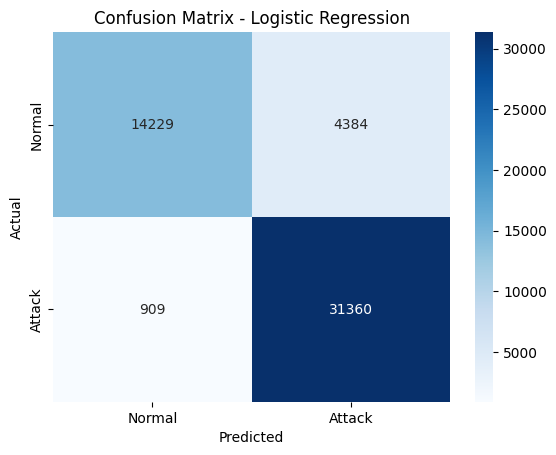

In [ ]:
#Calculate counts for the confusion matrix
#True Negative (label=0, prediction=0)
tn = lr_predictions.filter((lr_predictions.label == 0) & (lr_predictions.prediction == 0)).count()
#False Positive (label=0, prediction=1)
fp = lr_predictions.filter((lr_predictions.label == 0) & (lr_predictions.prediction == 1)).count()
#False Negative (label=1, prediction=0)
fn = lr_predictions.filter((lr_predictions.label == 1) & (lr_predictions.prediction == 0)).count()
#True Positive (label=1, prediction=1)
tp = lr_predictions.filter((lr_predictions.label == 1) & (lr_predictions.prediction == 1)).count()

#Create the confusion matrix (Actual vs. Predicted)
conf_matrix = np.array([
    [tn, fp],
    [fn, tp]
])

cm = conf_matrix

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Attack"],
            yticklabels=["Normal", "Attack"])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
lr_predictions.groupBy("label", "prediction").count().show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       1.0|31360|
|    1|       0.0|  909|
|    0|       0.0|14229|
|    0|       1.0| 4384|
+-----+----------+-----+



Explanation:  
We will get the correctly predicted 0 and 1 counts and incorrectly predicted 0 and 1 counts by visualising the prediction result.  

### Third model: Linear SVM

#### 3.1 Define the Linear SVM Model

In [ ]:
#Creating a model for Linear SVM
lsvc = LinearSVC(
    labelCol="label",       # target column
    featuresCol="features", # feature vector created by RFormula
    maxIter=10,             # maximum number of iterations
    regParam=0.0,           # regularization parameter
    tol=1e-6                # convergence tolerance
)

Explanation:  
== The code ==  
featuresCol="features" specifies the input feature vector column.  
In Spark, all features must be combined into one vector column, we will use the feature we created in RFormula.  
labelCol="label" is the target column.  
maxIter=10 controls the maximum number of training iterations. We need to set this because we need more iterations for better convergence, but too many will cause slow training. Therefore we need to find tune to find the best maxIter.  
regParam=0.0 is the regularization strength, used to prevent overfitting. 0.0 means no regularization, larger value represents stronger penalty.  
tol is the threshold. As the model improves, the changes it makes to the weights become smaller and smaller. If the improvement in the "loss function" (the error) between two iterations is less than the tol value we set, the model decides it has converged and stops training.  

### (d) fine-tune the model

In [ ]:
# Creates a grid of hyperparameters to test
lsvc_paramGrid = (ParamGridBuilder()
    .addGrid(lsvc.maxIter, [10, 20, 50])
    .addGrid(lsvc.regParam, [0.0, 0.01, 0.1])
    .addGrid(lsvc.tol, [1e-6, 1e-4, 1e-8])
    .build()
)

Explanation:  
It will run automatically to find the best attribute that fit the training data with each different groups of hyperparameter.  

#### 3.2 Train the Linear SVM Model

In [ ]:
# Record the start time
start_time = time.time()

# Define an evaluator (AUC)
lsvc_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

# Set up CrossValidator
lsvc_cv = CrossValidator(
    estimator=lsvc,                    # Linear SVM model
    estimatorParamMaps=lsvc_paramGrid, # grid we built just now
    evaluator=lsvc_evaluator,          # evaluate with AUC
    numFolds=5                         # k-fold cross validation
)

# Fit the CrossValidator to find the best Linear SVM model
lsvc_cvModel = lsvc_cv.fit(df_prepared)

# Record the end time
end_time = time.time()

# Calculate the execution time
lsvc_execution_time = end_time - start_time

# Extract the best model
lsvc_bestModel = lsvc_cvModel.bestModel

print("Best regParam:", lsvc_bestModel.getRegParam())
print("Best maxIter:", lsvc_bestModel.getMaxIter())
print("Best tol:", lsvc_bestModel.getTol())
print(f"Model Training completed in: {lsvc_execution_time:.2f} seconds")

Best regParam: 0.0
Best maxIter: 50
Best tol: 1e-06
Model Training completed in: 9950.24 seconds


Explanation:  
== The code ==  
MulticlassClassificationEvaluator: Used for multi class classification tasks.  
metricName="f1": evaluates models based on the f1-score.  

CrossValidator: automates hyperparameter tuning with cross-validation.  
estimator=lsvc: use the defined logistic regression model   estimatorParamMaps=lsvc_paramGrid: the hyperparameters to test  
evaluator=evaluator: how to measure performance (f1-score)  
numFolds=5: splits training data into 5 folds for cross-validation, and the best one is chosen. Spark does not provide a built‑in StratifiedKFold like scikit‑learn. For most datasets, especially when they are large or reasonably balanced, random k‑fold splits are sufficient and give stable performance estimates in Cross Validator. It is suitable when our dataset is stratified before and almost balanced.      

lsvc_cvModel = lsvc_cv.fit(df_prepared): fits the cross-validation process on the prepared training data. It will start to train multiple logistic regression models with different hyperparameters so use longer runtime. At the end, it will select the best-performing model based on f1-score (we set before).  

lsvc_bestModel = lsvc_cvModel.bestModel: The single Linear SVM model trained with the best hyperparameters. We will use this for predictions.  

We use execution time = end time - start time to calculate the execution time.

== The outcome ==  
Print out the tested best hyperparameter and execution time that will give the best outcome.

#### 3.3 Make predictions on test data

In [ ]:
#Record the start time
start_time = time.time()

# Make predictions on the prepared test data
lsvc_predictions = lsvc_bestModel.transform(test_df_prepared)

# Record the end time
end_time = time.time()

# Calculate the inference time
lsvc_inference_time = end_time - start_time

print(f"Model inference time: {lsvc_inference_time:.2f} seconds")

Model inference time: 0.05 seconds


Explanation:  
== The code ==  
Use the best model with best hyperparameter we found before to start prediction by using the test dataset.

### (e) evaluate the outcomes

#### 3.4 View sample predictions

In [ ]:
lsvc_predictions.select("label", "prediction", "rawPrediction").show(15)

+-----+----------+--------------------+
|label|prediction|       rawPrediction|
+-----+----------+--------------------+
|    1|       1.0|[-1.0202763958621...|
|    1|       1.0|[-1.4043712719654...|
|    1|       1.0|[-0.5865366133628...|
|    1|       1.0|[-1.3020863175053...|
|    1|       1.0|[-1.4670931480157...|
|    1|       1.0|[-1.3680467826969...|
|    1|       1.0|[-2.2476196217657...|
|    1|       1.0|[-1.0258301779018...|
|    1|       1.0|[-1.2227984570605...|
|    1|       1.0|[-1.2228014734537...|
|    1|       1.0|[-1.2227984570605...|
|    1|       1.0|[-2.6979757853061...|
|    1|       1.0|[-1.2138051921557...|
|    1|       1.0|[-2.5889707413234...|
|    1|       1.0|[-1.0038988379159...|
+-----+----------+--------------------+
only showing top 15 rows


Explanation:  
== The code ==  
Whis shows actual label, predicted label, and confidence of prediction. Let us visualise our prediction results.  

#### 3.5 AUC Calculation

In [ ]:
lsvc_auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC" )
lsvc_auc = lsvc_auc_evaluator.evaluate(lsvc_predictions)
print(f"Linear SVM AUC: {lsvc_auc * 100:.2f}%")

Linear SVM AUC: 97.30%


#### 3.6 Evaluate Linear SVM performance metrics

In [ ]:
# Initialize the evaluator
lsvc_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction"
)

# Calculate each metric by changing the metricName
lsvc_accuracy = lsvc_evaluator.evaluate(lsvc_predictions, {lsvc_evaluator.metricName: "accuracy"})
lsvc_precision = lsvc_evaluator.evaluate(lsvc_predictions, {lsvc_evaluator.metricName: "weightedPrecision"})
lsvc_recall = lsvc_evaluator.evaluate(lsvc_predictions, {lsvc_evaluator.metricName: "weightedRecall"})
lsvc_f1_score = lsvc_evaluator.evaluate(lsvc_predictions, {lsvc_evaluator.metricName: "f1"})

print("-" * 30)
print(f"Linear SVM Metrics:")
print("-" * 30)
print(f"Accuracy:  {lsvc_accuracy * 100:.2f}%")
print(f"Precision: {lsvc_precision * 100:.2f}%")
print(f"Recall:    {lsvc_recall * 100:.2f}%")
print(f"F1-Score:  {lsvc_f1_score * 100:.2f}%")

print("-" * 30)

------------------------------
Linear SVM Metrics:
------------------------------
Accuracy:  89.52%
Precision: 90.69%
Recall:    89.52%
F1-Score:  89.10%
------------------------------


#### 3.7 Show confusion matrix

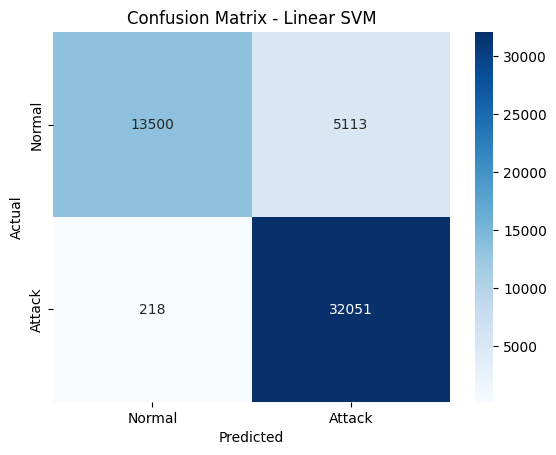

In [ ]:
# True Negative: label 0, prediction 0
lsvc_tn = lsvc_predictions.filter(
    (lsvc_predictions.label == 0) & (lsvc_predictions.prediction == 0)
).count()

#F alse Positive: label 0, prediction 1
lsvc_fp = lsvc_predictions.filter(
    (lsvc_predictions.label == 0) & (lsvc_predictions.prediction == 1)
).count()

# False Negative: label 1, prediction 0
lsvc_fn = lsvc_predictions.filter(
    (lsvc_predictions.label == 1) & (lsvc_predictions.prediction == 0)
).count()

# True Positive: label 1, prediction 1
lsvc_tp = lsvc_predictions.filter(
    (lsvc_predictions.label == 1) & (lsvc_predictions.prediction == 1)
).count()

# [[TN, FP], [FN, TP]]
lsvc_confmatrix = np.array([[lsvc_tn, lsvc_fp],
                            [lsvc_fn, lsvc_tp]])

sns.heatmap(
    lsvc_confmatrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)
plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# Show counts in table form
lsvc_predictions.groupBy("label", "prediction").count().show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       1.0|32051|
|    1|       0.0|  218|
|    0|       0.0|13500|
|    0|       1.0| 5113|
+-----+----------+-----+



Explanation:  
We will get the correctly predicted 0 and 1 counts and incorrectly predicted 0 and 1 counts by visualising the prediction result.

## (4) Discuss the methods chosen, and explain each step of your project along with the Python code.
We had chosen Decision Tree, Logistic Regression and Linear SVM classification model.    

Decision Tree is a relatively simple and easy to interpret model. We can use the tree rules to find the best split therefore get the result. Finding the best split is an effective way to save our time from searching the logic inside to classify the data label. After training, we can get our decision tree, by testing, we can use the decision tree to quickly categorise our data to the corresponding prediction result with high accuracy. Additionally, Decision Tree is useful in handling both categorical and numerical data and works well with complex data. Last but not least, it can model non-linear relationships and no need to scale features. Thus, it becomes a popular choice in most of the machine learning tasks. Decision Tree is prone to overfitting, so it requires proper tuning (e.g. maxDepth, minInstancesPerNode) to improve generalization.  

For Logistic Regression, it is known as the standard baseline for binary classification. It estimates the probability that a given input belongs to a particular class using the logistic (sigmoid) function. The output is a value between 0 and 1, which makes it suitable for classification tasks. Logistic Regression is simple and scalable. It performs well when the data is linearly separable. Same as Decision Tree, it also provides probabilistic outputs, which allows us to evaluate model performance using metrics like AUC and F1-score. It is fast and simple and works well for linearly separable data, so it is suitable for this task. However, it is sensitive to outliers, we must do data preprocessing and normalization to avoid the outcome from affected by the outliers. Unlike Decision Tree, it cannot model non-linear patterns unless we add features.   

For Linear Support Vector Machine is chosen because it is one of the most powerful and robust algorithms for binary classifications. Unlike Logistic Regression, which can be easily skewed by data points far from the center, SVM only focuses on the Support Vectors (the points closest the boundary), make it not easily affected by noisy outliers. This makes SVM much more stable for security tasks like attack detection. Besides, it is high-dimensional efficiency. SVM is effective when dealing with many features. Since our project has 45 features and we perform one-hot encoding, SVM is able to handle these efficiently. Lastly, linear SVM is suitable to work with PySpark for large-scale datasets, providing a strong balance between speed and predictive power.  

In [ ]:
# Initialise list for results
results = []

# Append accuracy fo each model
results.append(("Decision Tree",
                f"{dt_accuracy * 100:.2f}%",
                f"{dt_auc * 100:.2f}%",
                f"{dt_precision * 100:.2f}%",
                f"{dt_recall * 100:.2f}%",
                f"{dt_f1_score * 100:.2f}%",
                f"{dt_inference_time:.2f}s"))

results.append(("Logistic Regression",
                f"{lr_accuracy * 100:.2f}%",
                f"{lr_auc * 100:.2f}%",
                f"{lr_precision * 100:.2f}%",
                f"{lr_recall * 100:.2f}%",
                f"{lr_f1_score * 100:.2f}%",
                f"{lr_inference_time:.2f}s"))

results.append(("Linear SVM",
                f"{lsvc_accuracy * 100:.2f}%",
                f"{lsvc_auc * 100:.2f}%",
                f"{lsvc_precision * 100:.2f}%",
                f"{lsvc_recall * 100:.2f}%",
                f"{lsvc_f1_score * 100:.2f}%",
                f"{lsvc_inference_time:.2f}s"))

# Create a DataFrame from results
results_df = spark.createDataFrame(
    results, ["Model", "Accuracy", "AUC", "Precision", "Recall", "F1-score", "Inference Time"]
)

# Show the performaces
results_df.show()


+-------------------+--------+------+---------+------+--------+--------------+
|              Model|Accuracy|   AUC|Precision|Recall|F1-score|Inference Time|
+-------------------+--------+------+---------+------+--------+--------------+
|      Decision Tree|  93.97%|97.38%|   93.99%|93.97%|  93.98%|         0.07s|
|Logistic Regression|  89.60%|97.42%|   90.03%|89.60%|  89.33%|         0.06s|
|         Linear SVM|  89.52%|97.30%|   90.69%|89.52%|  89.10%|         0.05s|
+-------------------+--------+------+---------+------+--------+--------------+



## (5) Compare the models’ performance.  
Overall, Decision Tree outperformed the other models across almost every metrics.  
Decision Tree gets the best accuracy (93.97%), as it handles both numerical and categorical features well after indexing and does not require feature scaling. Then, it is able to capture complex patterns in the data. However, Decision Tree are prone to overfitting and tuning by changing the maxDepth and minInstancesPerNode to improve generalisation. Thus, we can get a better accuracy result. 97.44% of AUC result indicates that the model is highly capable of distinguishing between "Normal" and "Attack" traffic even when the data is complex. High precision, recall and f1-score means that Decision Tree is good at both finding the attacks and being correct when it finds them.  


Logistic Regression shows weaker performance compared to Decision Tree but slightly better performance to LinearSVM. It records an accuracy of 89.60% and F1-Score of 89.33%, reflecting sensitivity to outliers and correlated features due to its likelihood‑based optimization. Precision (90.03%) and recall (89.60%) are also lower than Decision Tree, suggesting more misclassifications. Lower precision than LinearSVM means that Logistic Regression has lower True Positive Rate, meaning that it cannot accurately predict "Attack" record as "Attack". However, its AUC (97.42%) is nearly as high as Decision Tree, meaning it remains effective at ranking probabilities overall. Logistic Regression is relatively fast (0.06s), but not the fastest.

LinearSVM performs similarly to Logistic Regression in accuracy (89.52%) and recall (89.52%), but achieves slightly higher precision (90.69%). It is because SVM focuses on maximising the margin between classes, which can improve precision by being stricter about classification boundaries. However, its F1‑Score (89.10%) is slightly lower, reflecting that the balance between precision and recall is weaker compared to other classes. Its AUC (97.30%) is the lowest among the three, as linear SVM does not produce probability scores, the propabilities are approximated, which reduces ranking quality. The main advantage overall is the inference speed (0.05s), the fastest of all models, it might because classification reduces to a dot product and sign check.  

For the UNSW dataset, the Decision Tree is the most effective model. It provides the best balance of high-speed processing and high-precision detection, making it the ideal choice for this task.

## (6) Based on your experience in the assignments, write a brief report that compares Spark MLlib and Scikit-Learn (e.g., their pros/cons or similarity/difference).  

Spark MLib

Pros

Spark MLlib is good at handling bigger datasets. When working with the UNSW-NB15 dataset, Spark's ability to distribute tasks across multiple nodes was leveraged to process the large database so that the model could be scaled to a cluster envirnment.

Spark has better performance with the ability to distribute tasks across multiple nodes, which is used in the Decision Tress model with big datasets.

Spark MLlib is much better in data preprocessing due to its ability to work with big datasets that won't fit in a regular memory in local machine. For example, in Task 2, data from csv is read using spark which can handle larger datasets than pandas.

Cons

Smaller datasets show overhead due to the setup for distributed computing. In Task 2, spark.read.csv() can process large datasets better than pandas, but for smaller datasets, the efficieny of parallelization is not noticeable.

Scikit-Learn

Pros

Scikit learn is easier to use with its user friendly api, using functions like .fit() on a pipeline in Scikit learn then the more complex Spark setup.

Scikit learn is faster when used on smaller datasets, it executes operations like model training and evaluation efficiently within the memory limits of a single machine.

Cons

Scikit learn is slower for larger datasets, where the performance can worsen when it gets computationally expensive.


Similarities

Both frameworks offer preprocessing, allowing us to handle missing data.

Differences

Spark MLib uses distributed data processing, making it better for large datasets. It can process data by leveraging multiple nodes. While Scikit learn, on the other hand, is better for smaller datasets that would fit into the memory fo a single machine. For example, task1 uses Sckit learn Pandas Dataframe, which is better for smaller datasets.